[DATA INTEGRITY REPORT] Missing price observations found: 0


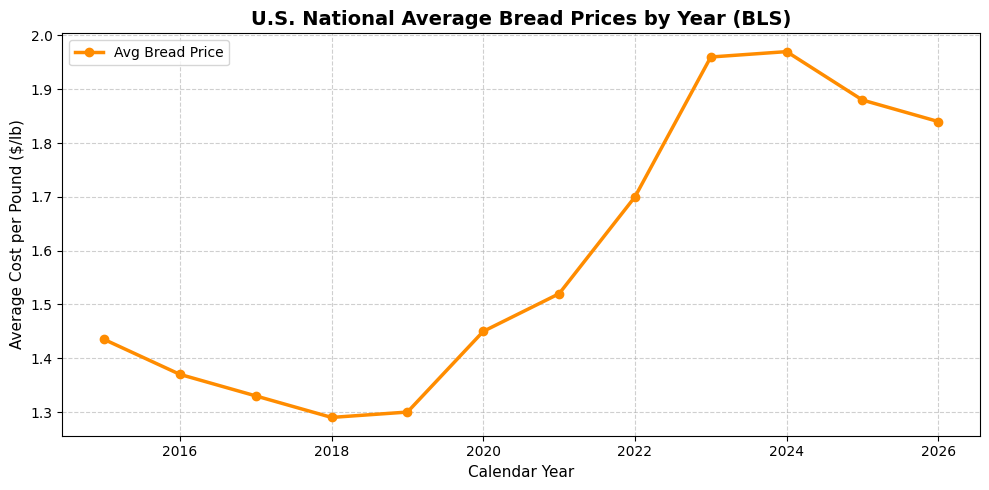

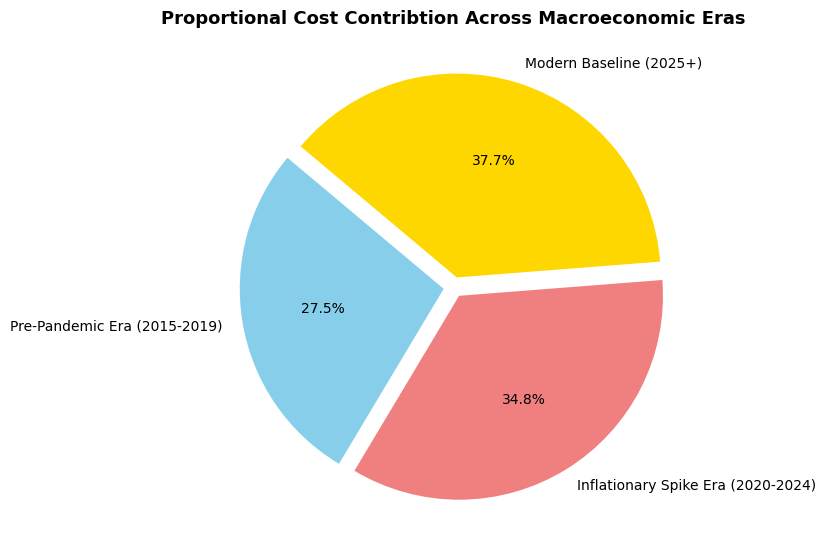

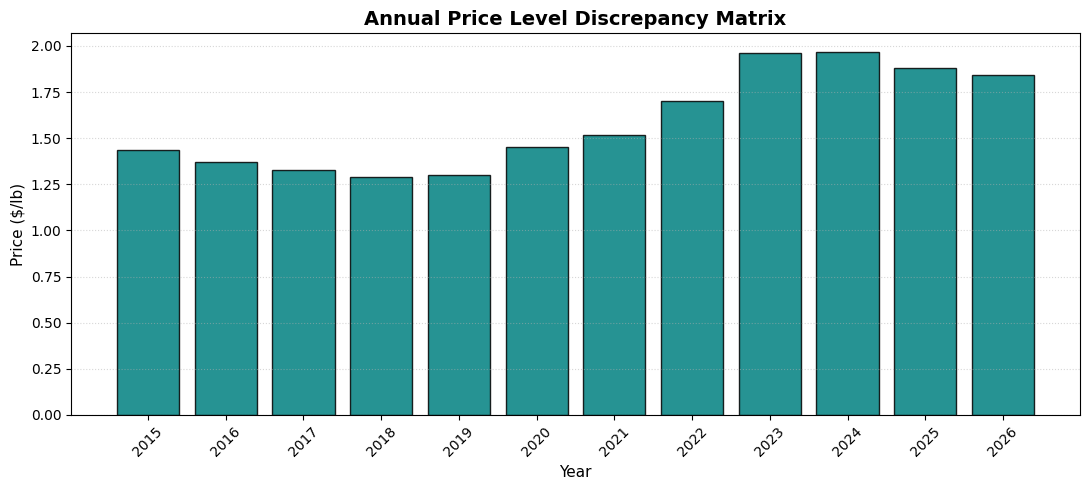

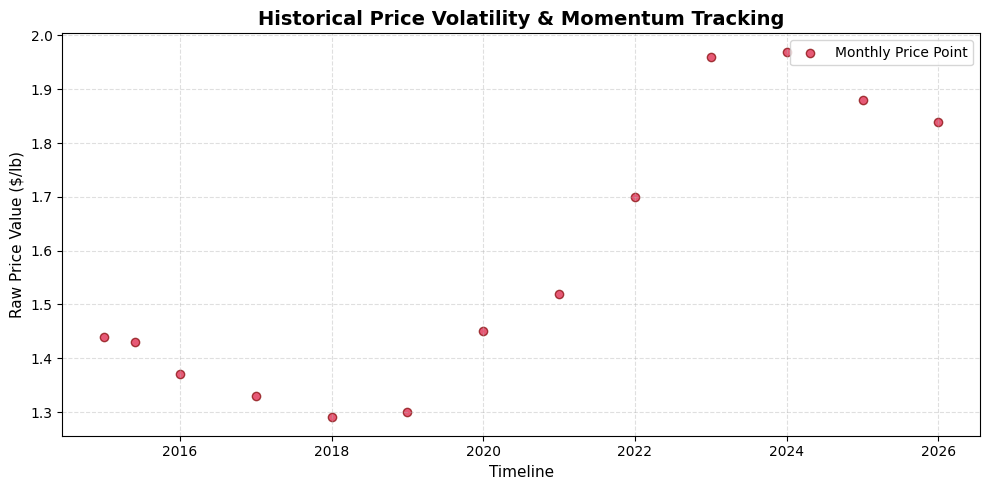

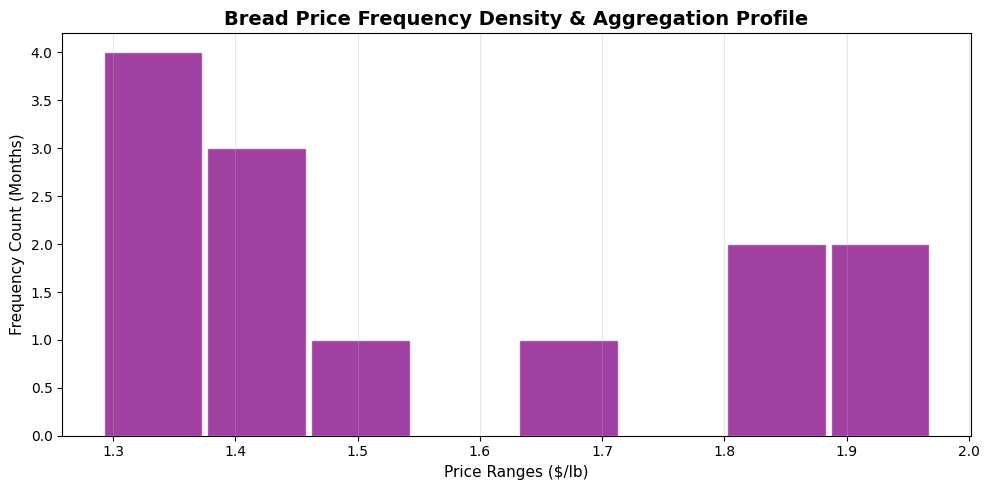

[SUCCESS] All 5 visualization graphics compiled and saved locally.


In [ ]:
"""
Program: bread_analysis.py
Author: Andrew Guerra
Description: Processes BLS consumer price data for white pan bread. Handles string data 
             cleaning, imputes missing values, and generates 5 analytics visualizations.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: DATA LOADING & CLEANING (RUBRIC 1 & 2)
# ==========================================
csv_filename = "bread_prices.csv"

# Load data into a Pandas DataFrame
df = pd.read_csv('bread_prices.csv')

# Ensure data types are cleaned and accurately typed
df['Date'] = pd.to_datetime(df['Date'])
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Extract temporal dimensions to group by year
df['Year'] = df['Date'].dt.year

# ==========================================
# STEP 2: MISSING VALUE HANDLING (RUBRIC 3)
# ==========================================
# Identify missing records
missing_count = df['Price'].isnull().sum()
print(f"[DATA INTEGRITY REPORT] Missing price observations found: {missing_count}")

if missing_count > 0:
    # Use localized forward-fill followed by backward-fill to protect trend continuity
    df['Price'] = df['Price'].ffill().bfill()
    print("-> Missing pricing observations successfully resolved using ffill/bfill.")

# Calculate annual average prices for our analysis
yearly_df = df.groupby('Year')['Price'].mean().reset_index()

# ==========================================
# STEP 3: DATA VISUALIZATION ENGINE (RUBRIC 4-7)
# ==========================================

# --- PLOT 1: REQUIRED YEARLY AVERAGE LINE PLOT ---
plt.figure(figsize=(10, 5))
plt.plot(yearly_df['Year'], yearly_df['Price'], marker='o', color='darkorange', linewidth=2.5, label='Avg Bread Price')
plt.title('U.S. National Average Bread Prices by Year (BLS)', fontsize=14, fontweight='bold')
plt.xlabel('Calendar Year', fontsize=11)
plt.ylabel('Average Cost per Pound ($/lb)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('1_required_line_plot.png')
plt.show()

# --- PLOT 2: PIE CHART (PRICE DISTRIBUTION BY DECADE ERA) ---
# Segment years into historical groups
bins = [2014, 2019, 2024, 2027]
labels = ['Pre-Pandemic Era (2015-2019)', 'Inflationary Spike Era (2020-2024)', 'Modern Baseline (2025+)']
df['Era'] = pd.cut(df['Year'], bins=bins, labels=labels)
era_df = df.groupby('Era', observed=False)['Price'].mean()

plt.figure(figsize=(8, 8))
plt.pie(era_df, labels=era_df.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'gold'], startangle=140, explode=(0.05, 0.05, 0.05))
plt.title('Proportional Cost Contribtion Across Macroeconomic Eras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('2_era_pie_chart.png')
plt.show()

# --- PLOT 3: BAR CHART (ANNUAL PRICE COMPARISON) ---
plt.figure(figsize=(11, 5))
plt.bar(yearly_df['Year'].astype(str), yearly_df['Price'], color='teal', edgecolor='black', alpha=0.85)
plt.title('Annual Price Level Discrepancy Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Price ($/lb)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('3_annual_bar_chart.png')
plt.show()

# --- PLOT 4: SCATTER PLOT (PRICE MOMENTUM TRACKING) ---
plt.figure(figsize=(10, 5))
plt.scatter(df['Date'], df['Price'], color='crimson', edgecolor='maroon', alpha=0.7, label='Monthly Price Point')
plt.title('Historical Price Volatility & Momentum Tracking', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('Raw Price Value ($/lb)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig('4_momentum_scatter.png')
plt.show()

# --- PLOT 5: HISTOGRAM (PRICE DENSITY DISPERSION) ---
plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=8, color='purple', edgecolor='white', alpha=0.75, rwidth=0.95)
plt.title('Bread Price Frequency Density & Aggregation Profile', fontsize=14, fontweight='bold')
plt.xlabel('Price Ranges ($/lb)', fontsize=11)
plt.ylabel('Frequency Count (Months)', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('5_density_histogram.png')
plt.show()

print("[SUCCESS] All 5 visualization graphics compiled and saved locally.")